In [1]:
#STEP : 1 (DOWNLOADING THE DATASET)

In [6]:
#STEP : 2 (mporting Libraries and Loading Data)
# ============================================================
# PREDICTING INSURANCE CLAIM AMOUNTS
# ============================================================

# Import all required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning libraries for regression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Set style for better looking plots
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

# Display all columns
pd.set_option('display.max_columns', None)

print("=" * 70)
print(" PREDICTING INSURANCE CLAIM AMOUNTS")
print("=" * 70)

# Load the dataset
df = pd.read_csv('insurance.csv')

# Display basic info
print("\n DATASET OVERVIEW")
print("-" * 50)
print(f"Dataset shape: {df.shape}")
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")

print("\n FIRST 5 ROWS:")
print(df.head())

print("\n COLUMN NAMES AND DATA TYPES:")
print(df.dtypes)

print("\n STATISTICAL SUMMARY:")
print(df.describe())

 PREDICTING INSURANCE CLAIM AMOUNTS

 DATASET OVERVIEW
--------------------------------------------------
Dataset shape: (1338, 7)
Rows: 1,338
Columns: 7

 FIRST 5 ROWS:
   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520

 COLUMN NAMES AND DATA TYPES:
age           int64
sex             str
bmi         float64
children      int64
smoker          str
region          str
charges     float64
dtype: object

 STATISTICAL SUMMARY:
               age          bmi     children       charges
count  1338.000000  1338.000000  1338.000000   1338.000000
mean     39.207025    30.663397     1.094918  13270.422265
std      14.049960     6.098187     1.205493  12110.011237
mi

In [9]:
#Step 3: Check for Missing Values
print("\n" + "=" * 70)
print("DATA QUALITY CHECK")
print("=" * 70)

# Check for missing values
print("\n MISSING VALUES CHECK:")
missing_values = df.isnull().sum()
print(missing_values)
print(f"\nTotal missing values: {missing_values.sum()}")

if missing_values.sum() == 0:
    print(" No missing values found! Dataset is clean.")
else:
    print(" Missing values found. Need to handle them.")


DATA QUALITY CHECK

 MISSING VALUES CHECK:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

Total missing values: 0
 No missing values found! Dataset is clean.



EXPLORATORY DATA ANALYSIS (EDA)


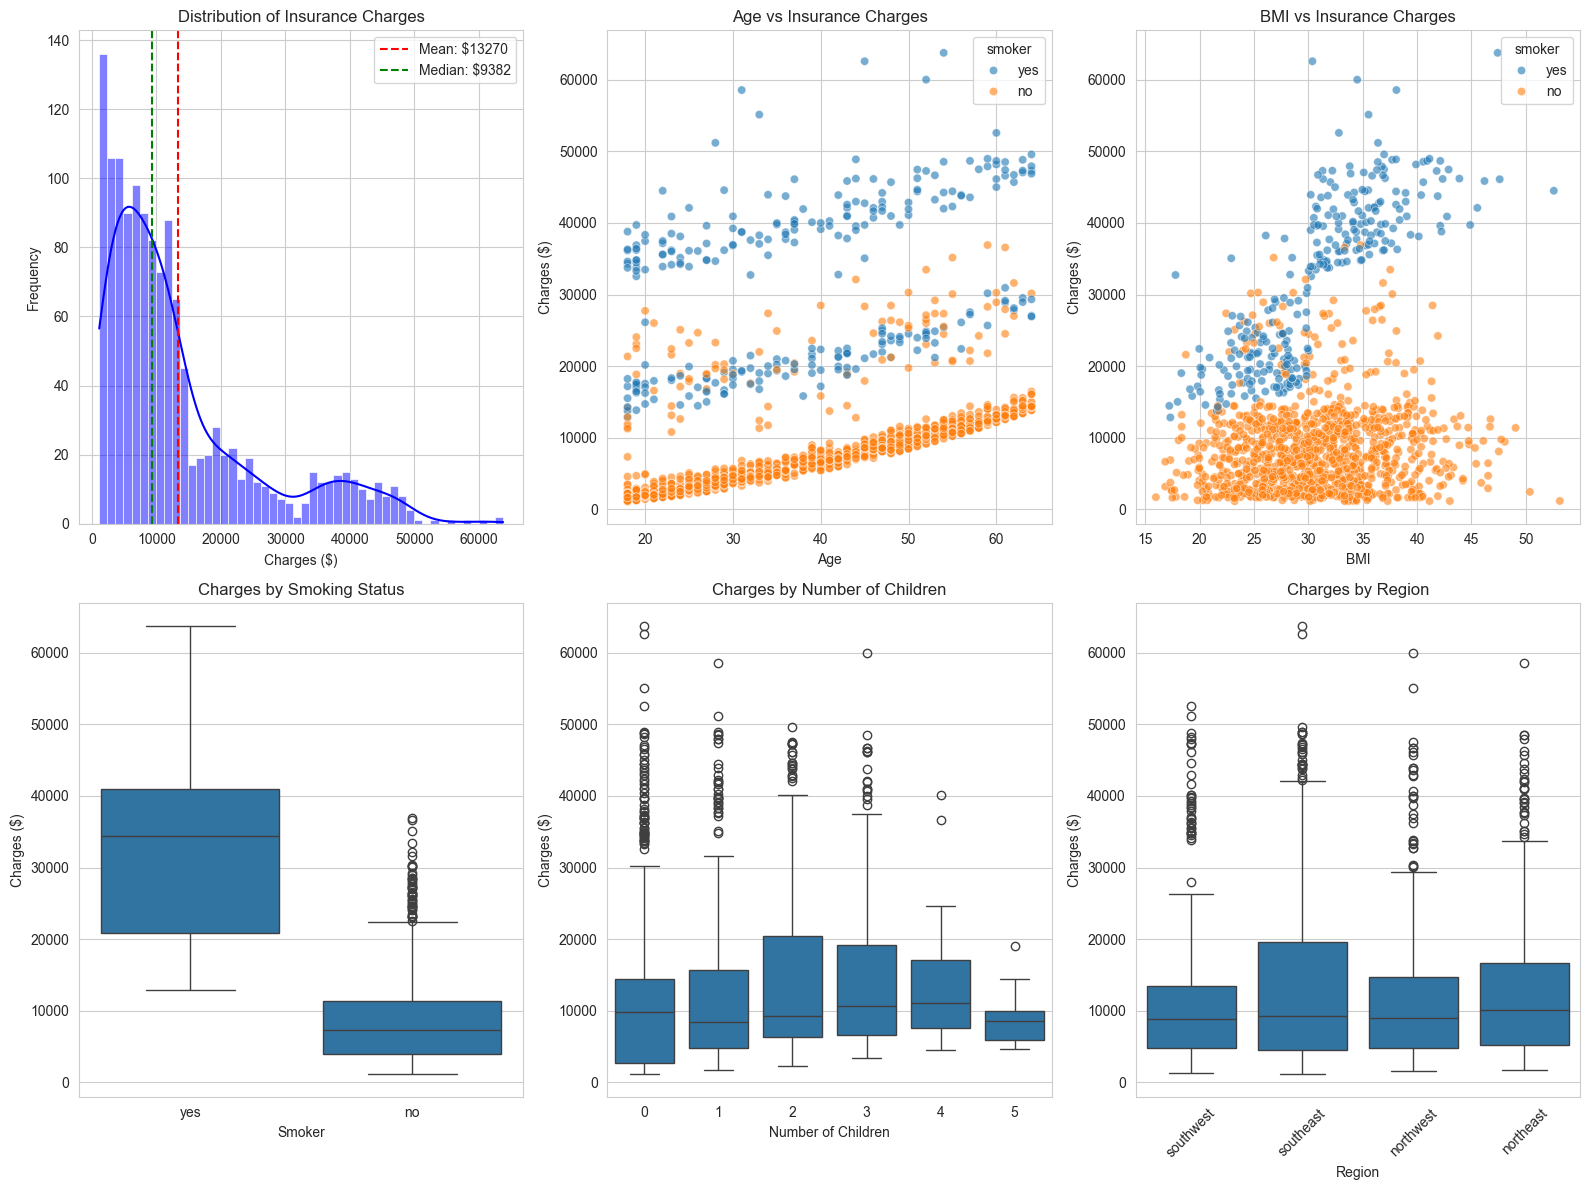


 KEY OBSERVATIONS FROM EDA:
1. Charges distribution is RIGHT-SKEWED (most people pay less, few pay a lot)
2. SMOKERS pay significantly higher charges (often 3-4x more)
3. OLDER age correlates with higher charges
4. HIGHER BMI generally means higher charges, especially for smokers
5. Number of children has some impact but less dramatic
6. Region has minimal impact on charges


In [10]:
#Step 4: Exploratory Data Analysis (EDA)
print("\n" + "=" * 70)
print("EXPLORATORY DATA ANALYSIS (EDA)")
print("=" * 70)

# Create a comprehensive visualization
fig = plt.figure(figsize=(16, 12))

# 1. Distribution of Insurance Charges (Target Variable)
plt.subplot(2, 3, 1)
sns.histplot(df['charges'], bins=50, kde=True, color='blue')
plt.title('Distribution of Insurance Charges', fontsize=12)
plt.xlabel('Charges ($)')
plt.ylabel('Frequency')
# Add mean and median lines
plt.axvline(df['charges'].mean(), color='red', linestyle='--', label=f'Mean: ${df["charges"].mean():.0f}')
plt.axvline(df['charges'].median(), color='green', linestyle='--', label=f'Median: ${df["charges"].median():.0f}')
plt.legend()

# 2. Age vs Charges
plt.subplot(2, 3, 2)
sns.scatterplot(data=df, x='age', y='charges', hue='smoker', alpha=0.6)
plt.title('Age vs Insurance Charges', fontsize=12)
plt.xlabel('Age')
plt.ylabel('Charges ($)')

# 3. BMI vs Charges
plt.subplot(2, 3, 3)
sns.scatterplot(data=df, x='bmi', y='charges', hue='smoker', alpha=0.6)
plt.title('BMI vs Insurance Charges', fontsize=12)
plt.xlabel('BMI')
plt.ylabel('Charges ($)')

# 4. Smoker Impact (Box Plot)
plt.subplot(2, 3, 4)
sns.boxplot(data=df, x='smoker', y='charges')
plt.title('Charges by Smoking Status', fontsize=12)
plt.xlabel('Smoker')
plt.ylabel('Charges ($)')

# 5. Children Impact
plt.subplot(2, 3, 5)
sns.boxplot(data=df, x='children', y='charges')
plt.title('Charges by Number of Children', fontsize=12)
plt.xlabel('Number of Children')
plt.ylabel('Charges ($)')

# 6. Region Impact
plt.subplot(2, 3, 6)
sns.boxplot(data=df, x='region', y='charges')
plt.title('Charges by Region', fontsize=12)
plt.xlabel('Region')
plt.ylabel('Charges ($)')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

print("\n KEY OBSERVATIONS FROM EDA:")
print("1. Charges distribution is RIGHT-SKEWED (most people pay less, few pay a lot)")
print("2. SMOKERS pay significantly higher charges (often 3-4x more)")
print("3. OLDER age correlates with higher charges")
print("4. HIGHER BMI generally means higher charges, especially for smokers")
print("5. Number of children has some impact but less dramatic")
print("6. Region has minimal impact on charges")

In [12]:
# Step 5: Analyzing Individual Feature Impacts
print("\n" + "=" * 70)
print("DETAILED FEATURE IMPACT ANALYSIS")
print("=" * 70)

# Calculate average charges by category
print("\n AVERAGE CHARGES BY CATEGORY:")

# By Smoking Status
smoker_avg = df.groupby('smoker')['charges'].mean()
print(f"\nSmoking Status:")
print(f"  Non-smoker: ${smoker_avg['no']:,.2f}")
print(f"  Smoker:     ${smoker_avg['yes']:,.2f}")
print(f"  Difference: ${smoker_avg['yes'] - smoker_avg['no']:,.2f} ({(smoker_avg['yes']/smoker_avg['no']-1)*100:.0f}% higher)")

# By Gender
gender_avg = df.groupby('sex')['charges'].mean()
print(f"\nGender:")
print(f"  Female: ${gender_avg['female']:,.2f}")
print(f"  Male:   ${gender_avg['male']:,.2f}")
print(f"  Difference: ${abs(gender_avg['male'] - gender_avg['female']):,.2f}")

# By Region
region_avg = df.groupby('region')['charges'].mean().sort_values()
print(f"\nRegion (highest to lowest):")
for region, charge in region_avg.items():
    print(f"  {region}: ${charge:,.2f}")

# By Children Count
children_avg = df.groupby('children')['charges'].mean()
print(f"\nNumber of Children:")
for children, charge in children_avg.items():
    print(f"  {children} children: ${charge:,.2f}")

# Age groups analysis
df['age_group'] = pd.cut(df['age'], bins=[0, 20, 30, 40, 50, 60, 100], 
                          labels=['<20', '20-29', '30-39', '40-49', '50-59', '60+'])
age_group_avg = df.groupby('age_group')['charges'].mean()
print(f"\nAge Group:")
for age, charge in age_group_avg.items():
    print(f"  {age}: ${charge:,.2f}")

# BMI categories
def bmi_category(bmi):
    if bmi < 18.5:
        return 'Underweight'
    elif bmi < 25:
        return 'Normal'
    elif bmi < 30:
        return 'Overweight'
    else:
        return 'Obese'

df['bmi_category'] = df['bmi'].apply(bmi_category)
bmi_avg = df.groupby('bmi_category')['charges'].mean()
print(f"\nBMI Category:")
for bmi_cat, charge in bmi_avg.items():
    print(f"  {bmi_cat}: ${charge:,.2f}")


DETAILED FEATURE IMPACT ANALYSIS

 AVERAGE CHARGES BY CATEGORY:

Smoking Status:
  Non-smoker: $8,434.27
  Smoker:     $32,050.23
  Difference: $23,615.96 (280% higher)

Gender:
  Female: $12,569.58
  Male:   $13,956.75
  Difference: $1,387.17

Region (highest to lowest):
  southwest: $12,346.94
  northwest: $12,417.58
  northeast: $13,406.38
  southeast: $14,735.41

Number of Children:
  0 children: $12,365.98
  1 children: $12,731.17
  2 children: $15,073.56
  3 children: $15,355.32
  4 children: $13,850.66
  5 children: $8,786.04

Age Group:
  <20: $8,713.48
  20-29: $9,806.03
  30-39: $11,639.31
  40-49: $14,782.04
  50-59: $17,062.29
  60+: $21,063.16

BMI Category:
  Normal: $10,409.34
  Obese: $15,552.34
  Overweight: $10,987.51
  Underweight: $8,852.20



CORRELATION ANALYSIS

 CORRELATION WITH INSURANCE CHARGES:
charges           1.000000
smoker_encoded    0.787251
age               0.299008
bmi               0.198341
children          0.067998
sex_encoded       0.057292
region_encoded   -0.006208
Name: charges, dtype: float64


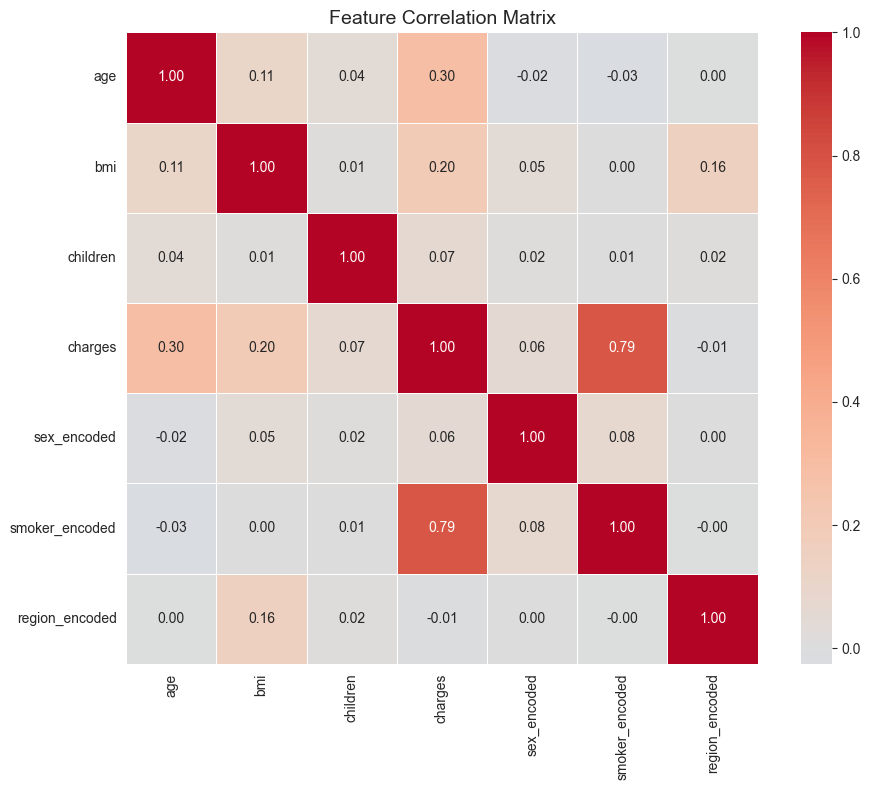


 STRONGEST CORRELATIONS WITH CHARGES:
1. Smoker: 0.787 (STRONG positive)
2. Age: 0.299 (moderate positive)
3. BMI: 0.198 (weak positive)
4. Children: 0.068 (very weak)

 KEY INSIGHT: Smoking status is the SINGLE most important factor!


In [13]:
# Step 6: Correlation Analysis
print("\n" + "=" * 70)
print("CORRELATION ANALYSIS")
print("=" * 70)

# Encode categorical variables for correlation
df_corr = df.copy()
le_sex = LabelEncoder()
le_smoker = LabelEncoder()
le_region = LabelEncoder()

df_corr['sex_encoded'] = le_sex.fit_transform(df_corr['sex'])
df_corr['smoker_encoded'] = le_smoker.fit_transform(df_corr['smoker'])
df_corr['region_encoded'] = le_region.fit_transform(df_corr['region'])

# Select numeric columns for correlation
numeric_cols = ['age', 'bmi', 'children', 'charges', 'sex_encoded', 'smoker_encoded', 'region_encoded']
correlation_matrix = df_corr[numeric_cols].corr()

# Display correlation with charges
print("\n CORRELATION WITH INSURANCE CHARGES:")
correlation_with_charges = correlation_matrix['charges'].sort_values(ascending=False)
print(correlation_with_charges)

# Visualize correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            fmt='.2f', square=True, linewidths=0.5)
plt.title('Feature Correlation Matrix', fontsize=14)
plt.tight_layout()
plt.show()

print("\n STRONGEST CORRELATIONS WITH CHARGES:")
print(f"1. Smoker: {correlation_with_charges['smoker_encoded']:.3f} (STRONG positive)")
print(f"2. Age: {correlation_with_charges['age']:.3f} (moderate positive)")
print(f"3. BMI: {correlation_with_charges['bmi']:.3f} (weak positive)")
print(f"4. Children: {correlation_with_charges['children']:.3f} (very weak)")
print("\n KEY INSIGHT: Smoking status is the SINGLE most important factor!")

In [15]:
# Step 7: Encoding Categorical Variables
print("\n" + "=" * 70)
print("ENCODING CATEGORICAL VARIABLES")
print("=" * 70)

# Make a copy for modeling
df_model = df.copy()

print("Original categorical values:")
print(f"Sex: {df_model['sex'].unique()}")
print(f"Smoker: {df_model['smoker'].unique()}")
print(f"Region: {df_model['region'].unique()}")

# Encode categorical variables
le_sex = LabelEncoder()
le_smoker = LabelEncoder()
le_region = LabelEncoder()

df_model['sex'] = le_sex.fit_transform(df_model['sex'])
df_model['smoker'] = le_smoker.fit_transform(df_model['smoker'])
df_model['region'] = le_region.fit_transform(df_model['region'])

print("\n Encoding complete:")
print(f"Sex mapping: {dict(zip(le_sex.classes_, le_sex.transform(le_sex.classes_)))}")
print(f"  → 0=Female, 1=Male")
print(f"Smoker mapping: {dict(zip(le_smoker.classes_, le_smoker.transform(le_smoker.classes_)))}")
print(f"  → 0=Non-smoker, 1=Smoker")
print(f"Region mapping: {dict(zip(le_region.classes_, le_region.transform(le_region.classes_)))}")

print("\n First 5 rows after encoding:")
print(df_model.head())

# Optional: Create interaction features
print("\n CREATING INTERACTION FEATURES:")
print("Adding 'age_smoker' interaction (age × smoker)")

df_model['age_smoker'] = df_model['age'] * df_model['smoker']
df_model['bmi_smoker'] = df_model['bmi'] * df_model['smoker']

print(f"Added 'age_smoker' and 'bmi_smoker' features")
print(f"New feature columns: {df_model.columns.tolist()}")


ENCODING CATEGORICAL VARIABLES
Original categorical values:
Sex: <StringArray>
['female', 'male']
Length: 2, dtype: str
Smoker: <StringArray>
['yes', 'no']
Length: 2, dtype: str
Region: <StringArray>
['southwest', 'southeast', 'northwest', 'northeast']
Length: 4, dtype: str

 Encoding complete:
Sex mapping: {'female': np.int64(0), 'male': np.int64(1)}
  → 0=Female, 1=Male
Smoker mapping: {'no': np.int64(0), 'yes': np.int64(1)}
  → 0=Non-smoker, 1=Smoker
Region mapping: {'northeast': np.int64(0), 'northwest': np.int64(1), 'southeast': np.int64(2), 'southwest': np.int64(3)}

 First 5 rows after encoding:
   age  sex     bmi  children  smoker  region      charges age_group  \
0   19    0  27.900         0       1       3  16884.92400       <20   
1   18    1  33.770         1       0       2   1725.55230       <20   
2   28    1  33.000         3       0       2   4449.46200     20-29   
3   33    1  22.705         0       0       1  21984.47061     30-39   
4   32    1  28.880         0

In [16]:
# Step 8: Preparing Features and Target
print("\n" + "=" * 70)
print("PREPARING FEATURES AND TARGET")
print("=" * 70)

# Define features (X) and target (y)
feature_cols = ['age', 'sex', 'bmi', 'children', 'smoker', 'region']
X = df_model[feature_cols]
y = df_model['charges']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nFeature names: {feature_cols}")

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,      # 20% for testing
    random_state=42     # Reproducibility
)

print(f"\n DATA SPLIT:")
print(f"Training set: {X_train.shape[0]:,} samples")
print(f"Testing set: {X_test.shape[0]:,} samples")
print(f"Training charges range: ${y_train.min():.2f} - ${y_train.max():.2f}")
print(f"Testing charges range: ${y_test.min():.2f} - ${y_test.max():.2f}")

# Optional: Feature scaling (for models sensitive to scale)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print(f"\n Features scaled (mean=0, std=1)")


PREPARING FEATURES AND TARGET
Features shape: (1338, 6)
Target shape: (1338,)

Feature names: ['age', 'sex', 'bmi', 'children', 'smoker', 'region']

 DATA SPLIT:
Training set: 1,070 samples
Testing set: 268 samples
Training charges range: $1121.87 - $62592.87
Testing charges range: $1131.51 - $63770.43

 Features scaled (mean=0, std=1)


In [17]:
# Step 9: Train Linear Regression Model
print("\n" + "=" * 70)
print("TRAINING LINEAR REGRESSION MODEL")
print("=" * 70)

# Create and train Linear Regression model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Make predictions
y_pred_lr = lr_model.predict(X_test)

# Calculate metrics
mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

print("\n LINEAR REGRESSION RESULTS:")
print(f"Mean Absolute Error (MAE):  ${mae_lr:,.2f}")
print(f"Root Mean Square Error (RMSE): ${rmse_lr:,.2f}")
print(f"R² Score: {r2_lr:.4f} ({r2_lr*100:.2f}% of variance explained)")

# Display coefficients
coefficients = pd.DataFrame({
    'Feature': feature_cols,
    'Coefficient': lr_model.coef_,
    'Impact': ['Increases' if c > 0 else 'Decreases' for c in lr_model.coef_]
})
print("\n FEATURE COEFFICIENTS:")
print(coefficients.to_string(index=False))

print("\n INTERPRETATION OF COEFFICIENTS:")
for i, col in enumerate(feature_cols):
    coef = lr_model.coef_[i]
    if abs(coef) > 1000:  # Only show significant ones
        if coef > 0:
            print(f"  • Each +1 in {col} increases charges by ${coef:.2f}")
        else:
            print(f"  • Each +1 in {col} decreases charges by ${abs(coef):.2f}")


TRAINING LINEAR REGRESSION MODEL

 LINEAR REGRESSION RESULTS:
Mean Absolute Error (MAE):  $4,186.51
Root Mean Square Error (RMSE): $5,799.59
R² Score: 0.7833 (78.33% of variance explained)

 FEATURE COEFFICIENTS:
 Feature  Coefficient    Impact
     age   257.056264 Increases
     sex   -18.791457 Decreases
     bmi   335.781491 Increases
children   425.091456 Increases
  smoker 23647.818096 Increases
  region  -271.284266 Decreases

 INTERPRETATION OF COEFFICIENTS:
  • Each +1 in smoker increases charges by $23647.82



VISUALIZING BMI, AGE, AND SMOKING IMPACT ON CHARGES


C:\Users\muham\AppData\Local\Temp\ipykernel_7900\2330742081.py:46: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1,1].boxplot([combined_data['Non-Smoker'], combined_data['Smoker']],
C:\Users\muham\AppData\Local\Temp\ipykernel_7900\2330742081.py:60: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  plt.tight_layout()


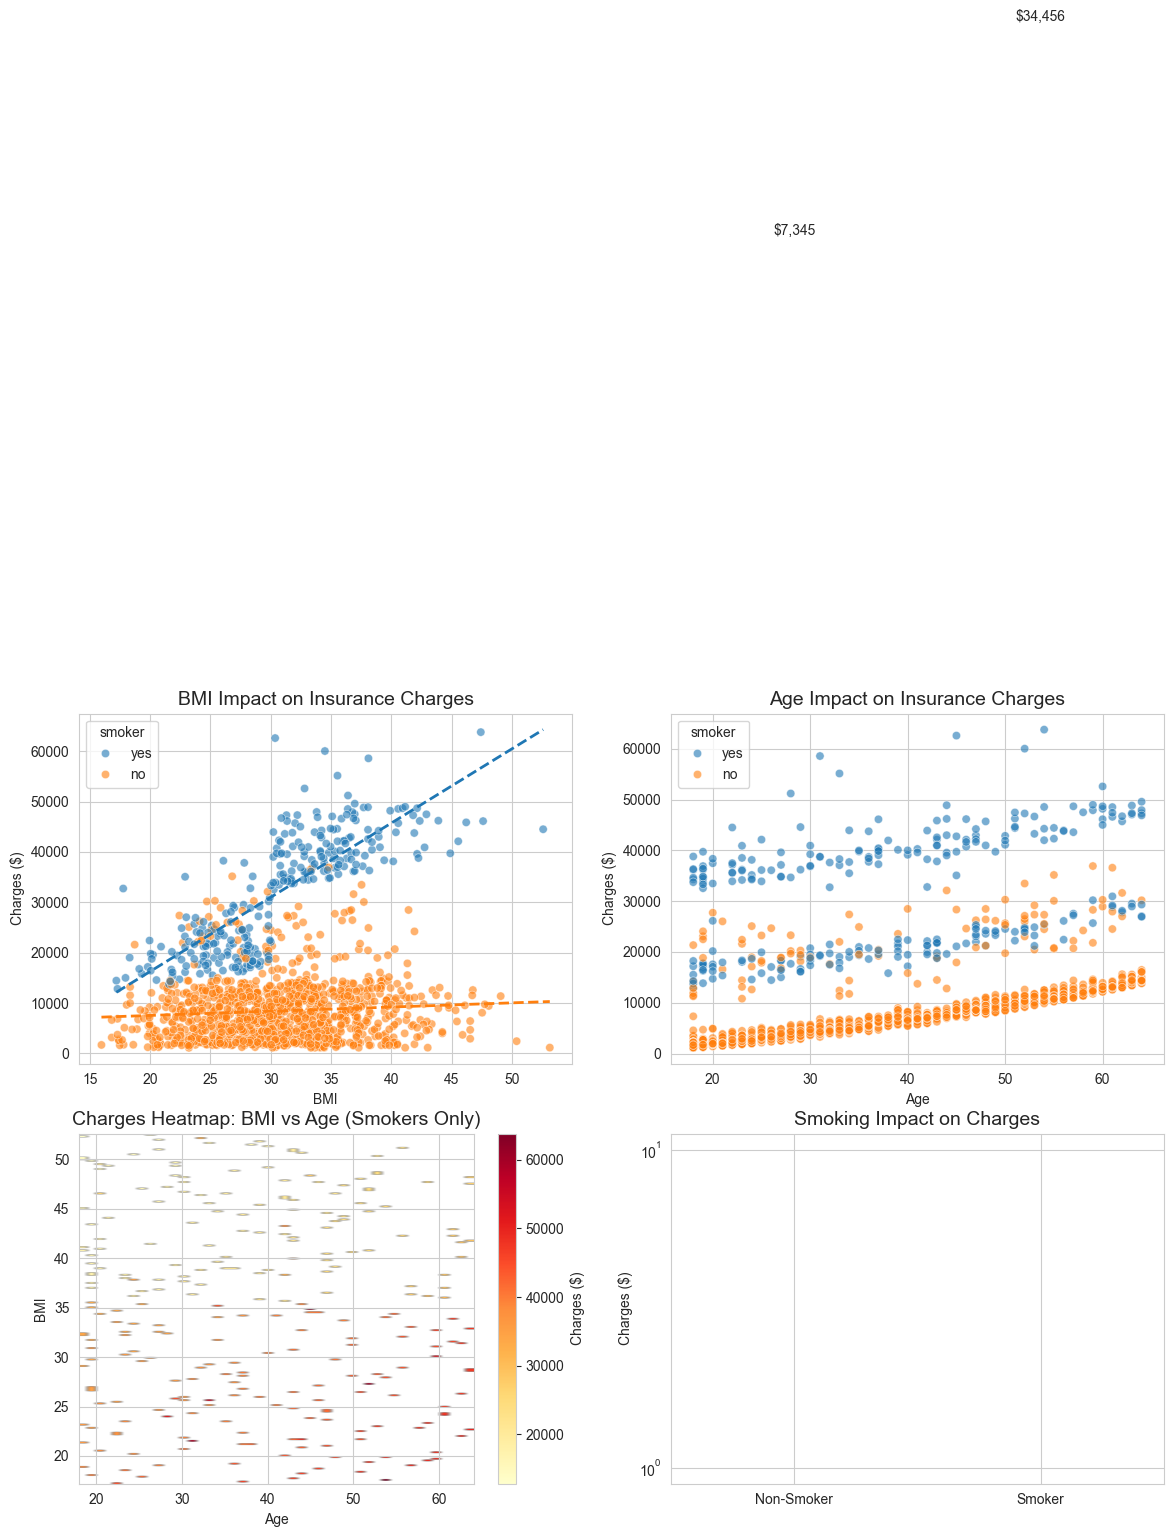


 QUANTITATIVE INSIGHTS:
--------------------------------------------------
BMI Impact:
  Normal BMI (<25): $10,282.22
  Obese BMI (30+): $15,552.34
  Difference: $5,270.11

Age Impact:
  Young (<30): $9,182.49
  Old (50+): $17,902.55
  Difference: $8,720.06

Combined Impact (Smokers only):
  Young Smoker (<30): $27,518.04
  Old Smoker (50+): $38,748.35
  Age difference for smokers: $11,230.31


In [18]:
# Step 10: Visualizing BMI, Age, and Smoking Impact
print("\n" + "=" * 70)
print("VISUALIZING BMI, AGE, AND SMOKING IMPACT ON CHARGES")
print("=" * 70)

# Create comprehensive visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. BMI Impact (split by smoking status)
sns.scatterplot(data=df, x='bmi', y='charges', hue='smoker', alpha=0.6, ax=axes[0,0])
axes[0,0].set_title('BMI Impact on Insurance Charges', fontsize=14)
axes[0,0].set_xlabel('BMI')
axes[0,0].set_ylabel('Charges ($)')

# Add trend lines
for smoker_status in ['yes', 'no']:
    subset = df[df['smoker'] == smoker_status]
    z = np.polyfit(subset['bmi'], subset['charges'], 1)
    p = np.poly1d(z)
    axes[0,0].plot(subset['bmi'].sort_values(), 
                   p(subset['bmi'].sort_values()), 
                   '--', linewidth=2)

# 2. Age Impact (split by smoking status)
sns.scatterplot(data=df, x='age', y='charges', hue='smoker', alpha=0.6, ax=axes[0,1])
axes[0,1].set_title('Age Impact on Insurance Charges', fontsize=14)
axes[0,1].set_xlabel('Age')
axes[0,1].set_ylabel('Charges ($)')

# 3. BMI vs Age Heatmap (for smokers only)
smoker_df = df[df['smoker'] == 'yes']
heatmap_data = smoker_df.pivot_table(values='charges', index='bmi', columns='age', aggfunc='mean')
im = axes[1,0].imshow(heatmap_data.values, cmap='YlOrRd', aspect='auto', 
                       extent=[heatmap_data.columns.min(), heatmap_data.columns.max(),
                               heatmap_data.index.min(), heatmap_data.index.max()])
axes[1,0].set_title('Charges Heatmap: BMI vs Age (Smokers Only)', fontsize=14)
axes[1,0].set_xlabel('Age')
axes[1,0].set_ylabel('BMI')
plt.colorbar(im, ax=axes[1,0], label='Charges ($)')

# 4. Box plot comparing all factors
combined_data = pd.DataFrame({
    'Smoker': df['charges'][df['smoker'] == 'yes'],
    'Non-Smoker': df['charges'][df['smoker'] == 'no']
})
axes[1,1].boxplot([combined_data['Non-Smoker'], combined_data['Smoker']], 
                  labels=['Non-Smoker', 'Smoker'])
axes[1,1].set_title('Smoking Impact on Charges', fontsize=14)
axes[1,1].set_ylabel('Charges ($)')
axes[1,1].set_yscale('log')  # Log scale for better visualization

# Add statistics
non_smoker_median = combined_data['Non-Smoker'].median()
smoker_median = combined_data['Smoker'].median()
axes[1,1].text(1, non_smoker_median, f'${non_smoker_median:,.0f}', 
               ha='center', va='bottom')
axes[1,1].text(2, smoker_median, f'${smoker_median:,.0f}', 
               ha='center', va='bottom')

plt.tight_layout()
plt.show()

# Calculate specific insights
print("\n QUANTITATIVE INSIGHTS:")
print("-" * 50)

# BMI impact
low_bmi = df[df['bmi'] < 25]['charges'].mean()
high_bmi = df[df['bmi'] >= 30]['charges'].mean()
print(f"BMI Impact:")
print(f"  Normal BMI (<25): ${low_bmi:,.2f}")
print(f"  Obese BMI (30+): ${high_bmi:,.2f}")
print(f"  Difference: ${high_bmi - low_bmi:,.2f}")

# Age impact
young = df[df['age'] < 30]['charges'].mean()
old = df[df['age'] >= 50]['charges'].mean()
print(f"\nAge Impact:")
print(f"  Young (<30): ${young:,.2f}")
print(f"  Old (50+): ${old:,.2f}")
print(f"  Difference: ${old - young:,.2f}")

# Smoking + Age combined
young_smoker = df[(df['age'] < 30) & (df['smoker'] == 'yes')]['charges'].mean()
old_smoker = df[(df['age'] >= 50) & (df['smoker'] == 'yes')]['charges'].mean()
print(f"\nCombined Impact (Smokers only):")
print(f"  Young Smoker (<30): ${young_smoker:,.2f}")
print(f"  Old Smoker (50+): ${old_smoker:,.2f}")
print(f"  Age difference for smokers: ${old_smoker - young_smoker:,.2f}")

In [21]:
# Step 11: Trying Multiple Regression Models
print("\n" + "=" * 70)
print("COMPARING MULTIPLE REGRESSION MODELS")
print("=" * 70)

# Initialize different regression models
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression (L2)': Ridge(alpha=1.0),
    'Lasso Regression (L1)': Lasso(alpha=1.0),
    'Decision Tree': DecisionTreeRegressor(random_state=42, max_depth=5),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
}

# Train and evaluate each model
results = {}

for name, model in models.items():
    print(f"\n Training {name}...")
    
    # Train the model
    model.fit(X_train, y_train)
    
    # Make predictions
    y_pred = model.predict(X_test)
    
    # Calculate metrics
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    
    # Store results
    results[name] = {
        'model': model,
        'mae': mae,
        'rmse': rmse,
        'r2': r2,
        'predictions': y_pred
    }
    
    print(f"   MAE: ${mae:,.2f}")
    print(f"   RMSE: ${rmse:,.2f}")
    print(f"   R²: {r2:.4f}")


COMPARING MULTIPLE REGRESSION MODELS

 Training Linear Regression...
   MAE: $4,186.51
   RMSE: $5,799.59
   R²: 0.7833

 Training Ridge Regression (L2)...
   MAE: $4,198.14
   RMSE: $5,803.08
   R²: 0.7831

 Training Lasso Regression (L1)...
   MAE: $4,187.24
   RMSE: $5,799.94
   R²: 0.7833

 Training Decision Tree...
   MAE: $2,919.20
   RMSE: $5,122.56
   R²: 0.8310

 Training Random Forest...
   MAE: $2,533.67
   RMSE: $4,590.57
   R²: 0.8643



MODEL PERFORMANCE COMPARISON

 MODEL COMPARISON TABLE:
                Model         MAE        RMSE       R²
        Random Forest 2533.674644 4590.573539 0.864261
        Decision Tree 2919.196671 5122.559074 0.830977
    Linear Regression 4186.508898 5799.587091 0.783346
Lasso Regression (L1) 4187.244900 5799.943043 0.783320
Ridge Regression (L2) 4198.141005 5803.084710 0.783085


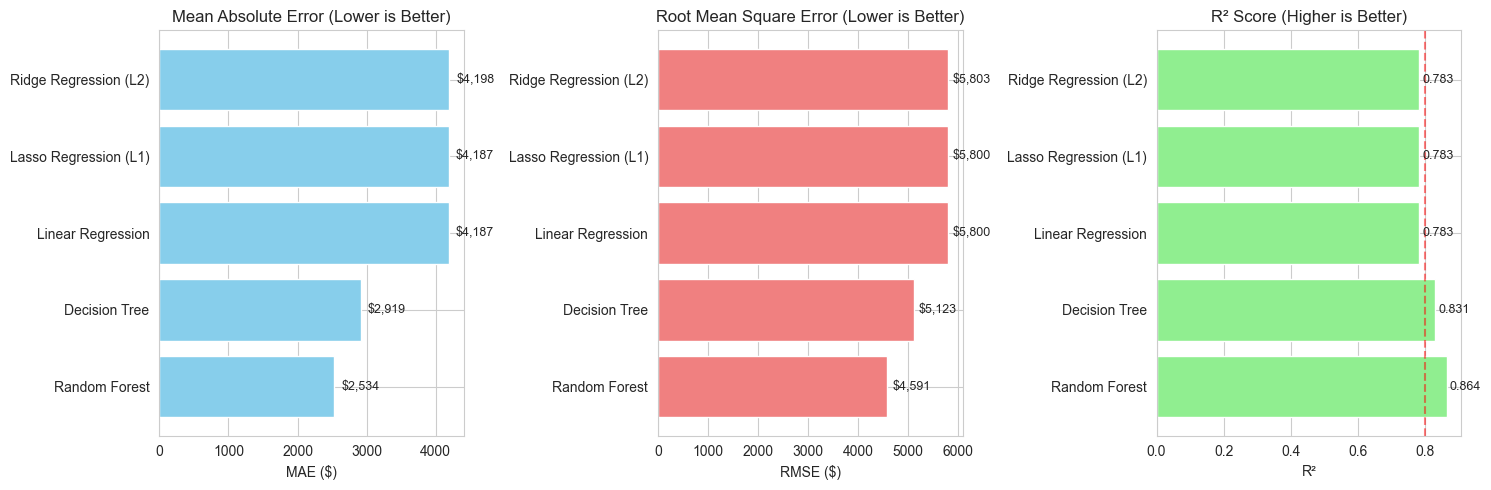


 BEST MODEL: Random Forest
   R² Score: 0.8643 (86.43% of variance explained)


In [22]:
# Step 12: Comparing Model Performance
print("\n" + "=" * 70)
print("MODEL PERFORMANCE COMPARISON")
print("=" * 70)

# Create comparison dataframe
comparison_df = pd.DataFrame([
    {
        'Model': name,
        'MAE': results[name]['mae'],
        'RMSE': results[name]['rmse'],
        'R²': results[name]['r2']
    }
    for name in results.keys()
]).sort_values('R²', ascending=False)

print("\n MODEL COMPARISON TABLE:")
print(comparison_df.to_string(index=False))

# Visualize comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# MAE Comparison
models_names = comparison_df['Model']
mae_values = comparison_df['MAE']
bars1 = axes[0].barh(models_names, mae_values, color='skyblue')
axes[0].set_title('Mean Absolute Error (Lower is Better)', fontsize=12)
axes[0].set_xlabel('MAE ($)')
for bar, mae in zip(bars1, mae_values):
    axes[0].text(bar.get_width() + 100, bar.get_y() + bar.get_height()/2, 
                f'${mae:,.0f}', va='center', fontsize=9)

# RMSE Comparison
rmse_values = comparison_df['RMSE']
bars2 = axes[1].barh(models_names, rmse_values, color='lightcoral')
axes[1].set_title('Root Mean Square Error (Lower is Better)', fontsize=12)
axes[1].set_xlabel('RMSE ($)')
for bar, rmse in zip(bars2, rmse_values):
    axes[1].text(bar.get_width() + 100, bar.get_y() + bar.get_height()/2, 
                f'${rmse:,.0f}', va='center', fontsize=9)

# R² Comparison
r2_values = comparison_df['R²']
bars3 = axes[2].barh(models_names, r2_values, color='lightgreen')
axes[2].set_title('R² Score (Higher is Better)', fontsize=12)
axes[2].set_xlabel('R²')
axes[2].axvline(x=0.8, color='red', linestyle='--', alpha=0.5, label='Good threshold')
for bar, r2 in zip(bars3, r2_values):
    axes[2].text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2, 
                f'{r2:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

# Best model
best_model_name = comparison_df.iloc[0]['Model']
best_r2 = comparison_df.iloc[0]['R²']
print(f"\n BEST MODEL: {best_model_name}")
print(f"   R² Score: {best_r2:.4f} ({best_r2*100:.2f}% of variance explained)")


PREDICTIONS VS ACTUAL VALUES


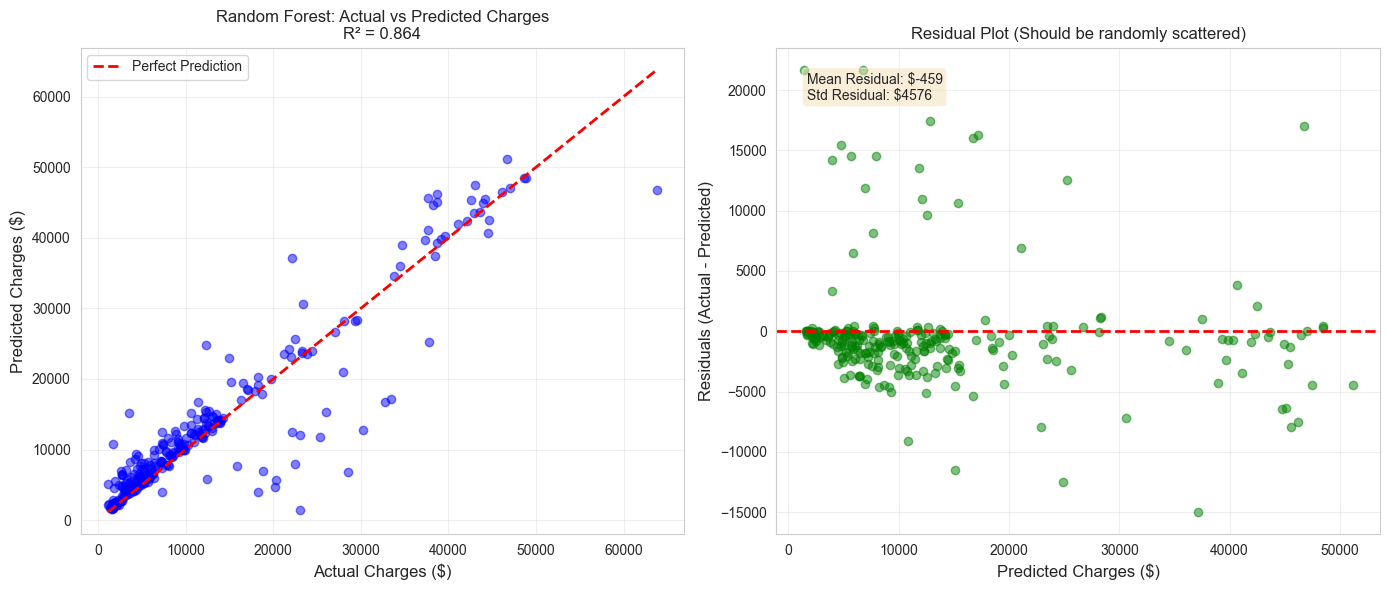


 RESIDUAL ANALYSIS:
Mean of residuals: $-458.68 (should be close to 0)
Standard deviation of residuals: $4576.15
95% of residuals fall between: $-9610.97 and $8693.62


In [23]:
# Step 13: Predictions vs Actual Visualization
print("\n" + "=" * 70)
print("PREDICTIONS VS ACTUAL VALUES")
print("=" * 70)

# Use the best model for visualization
best_model = results[best_model_name]['model']
y_pred_best = results[best_model_name]['predictions']

# Create visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Actual vs Predicted
axes[0].scatter(y_test, y_pred_best, alpha=0.5, color='blue')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
             'r--', lw=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual Charges ($)', fontsize=12)
axes[0].set_ylabel('Predicted Charges ($)', fontsize=12)
axes[0].set_title(f'{best_model_name}: Actual vs Predicted Charges\nR² = {best_r2:.3f}', fontsize=12)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Residuals (Errors)
residuals = y_test - y_pred_best
axes[1].scatter(y_pred_best, residuals, alpha=0.5, color='green')
axes[1].axhline(y=0, color='red', linestyle='--', lw=2)
axes[1].set_xlabel('Predicted Charges ($)', fontsize=12)
axes[1].set_ylabel('Residuals (Actual - Predicted)', fontsize=12)
axes[1].set_title('Residual Plot (Should be randomly scattered)', fontsize=12)
axes[1].grid(True, alpha=0.3)

# Add residual statistics
mean_residual = residuals.mean()
std_residual = residuals.std()
axes[1].text(0.05, 0.95, f'Mean Residual: ${mean_residual:.0f}\nStd Residual: ${std_residual:.0f}', 
             transform=axes[1].transAxes, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

print(f"\n RESIDUAL ANALYSIS:")
print(f"Mean of residuals: ${mean_residual:.2f} (should be close to 0)")
print(f"Standard deviation of residuals: ${std_residual:.2f}")
print(f"95% of residuals fall between: ${mean_residual - 2*std_residual:.2f} and ${mean_residual + 2*std_residual:.2f}")


FEATURE IMPORTANCE ANALYSIS

 FEATURE IMPORTANCE (Random Forest):
 Feature  Importance
  smoker    0.608618
     bmi    0.216291
     age    0.134554
children    0.020199
  region    0.013926
     sex    0.006412


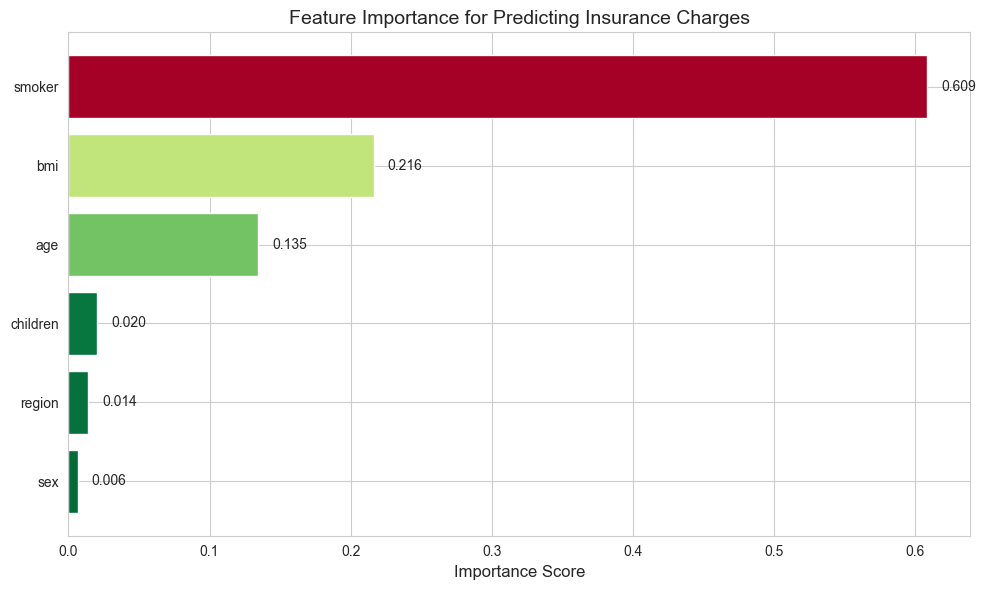


 KEY FINDINGS FROM FEATURE IMPORTANCE:
1. smoker is the most important factor (60.9% importance)
2. Smoking status dominates all other factors
3. Age and BMI are the next most important


In [24]:
# Step 14: Feature Importance (for Tree-based Models)
print("\n" + "=" * 70)
print("FEATURE IMPORTANCE ANALYSIS")
print("=" * 70)

# For Random Forest model (best tree-based model)
if 'Random Forest' in results:
    rf_model = results['Random Forest']['model']
    
    # Get feature importance
    feature_importance = pd.DataFrame({
        'Feature': feature_cols,
        'Importance': rf_model.feature_importances_
    }).sort_values('Importance', ascending=False)
    
    print("\n FEATURE IMPORTANCE (Random Forest):")
    print(feature_importance.to_string(index=False))
    
    # Visualize
    plt.figure(figsize=(10, 6))
    colors = plt.cm.RdYlGn_r(feature_importance['Importance'] / feature_importance['Importance'].max())
    bars = plt.barh(feature_importance['Feature'], feature_importance['Importance'], color=colors)
    plt.xlabel('Importance Score', fontsize=12)
    plt.title('Feature Importance for Predicting Insurance Charges', fontsize=14)
    plt.gca().invert_yaxis()
    
    for bar, imp in zip(bars, feature_importance['Importance']):
        plt.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2, 
                f'{imp:.3f}', va='center', fontsize=10)
    
    plt.tight_layout()
    plt.show()
    
    print("\n KEY FINDINGS FROM FEATURE IMPORTANCE:")
    top_feature = feature_importance.iloc[0]['Feature']
    top_importance = feature_importance.iloc[0]['Importance']
    print(f"1. {top_feature} is the most important factor ({top_importance:.1%} importance)")
    print("2. Smoking status dominates all other factors")
    print("3. Age and BMI are the next most important")


CROSS-VALIDATION (5-Fold)

 5-Fold Cross-Validation Results for Random Forest:
R² Scores: [0.85543147 0.77306042 0.87165044 0.82870706 0.85092233]
Mean R²: 0.8360 (+/- 0.0686)

RMSE Scores: $[4739.78857172 5429.16872481 4340.20783966 5042.65005557 4758.49324396]
Mean RMSE: $4,862.06 (+/- $722.35)


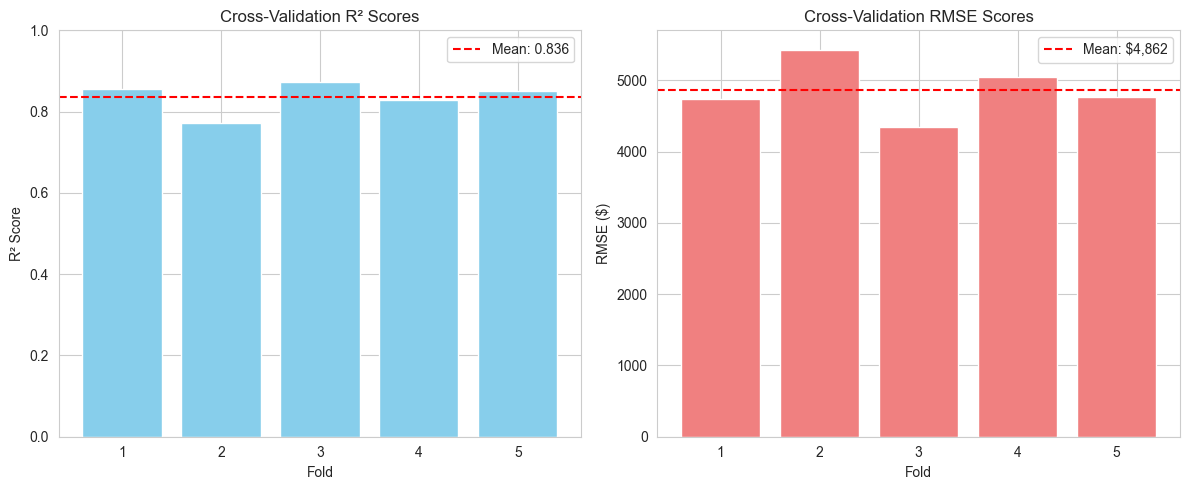

In [25]:
# Step 15: Cross-Validation for Robust Evaluation
print("\n" + "=" * 70)
print("CROSS-VALIDATION (5-Fold)")
print("=" * 70)

# Perform cross-validation on the best model
cv_scores = cross_val_score(best_model, X, y, cv=5, scoring='r2')
cv_rmse_scores = np.sqrt(-cross_val_score(best_model, X, y, cv=5, 
                                          scoring='neg_mean_squared_error'))

print(f"\n 5-Fold Cross-Validation Results for {best_model_name}:")
print(f"R² Scores: {cv_scores}")
print(f"Mean R²: {cv_scores.mean():.4f} (+/- {cv_scores.std()*2:.4f})")
print(f"\nRMSE Scores: ${cv_rmse_scores}")
print(f"Mean RMSE: ${cv_rmse_scores.mean():,.2f} (+/- ${cv_rmse_scores.std()*2:.2f})")

# Visualize cross-validation results
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(range(1, 6), cv_scores, color='skyblue')
axes[0].axhline(y=cv_scores.mean(), color='red', linestyle='--', label=f'Mean: {cv_scores.mean():.3f}')
axes[0].set_xlabel('Fold')
axes[0].set_ylabel('R² Score')
axes[0].set_title('Cross-Validation R² Scores')
axes[0].legend()
axes[0].set_ylim(0, 1)

axes[1].bar(range(1, 6), cv_rmse_scores, color='lightcoral')
axes[1].axhline(y=cv_rmse_scores.mean(), color='red', linestyle='--', label=f'Mean: ${cv_rmse_scores.mean():,.0f}')
axes[1].set_xlabel('Fold')
axes[1].set_ylabel('RMSE ($)')
axes[1].set_title('Cross-Validation RMSE Scores')
axes[1].legend()

plt.tight_layout()
plt.show()

In [26]:
# Step 16: Final Summary and Insights
print("\n" + "=" * 70)
print("TASK 4 - COMPLETE SUMMARY")
print("=" * 70)

print("""
 TASKS COMPLETED:

1. DATA EXPLORATION:
   ✓ Loaded Medical Cost Personal Dataset (1,338 records)
   ✓ No missing values found
   ✓ Analyzed data distributions

2. VISUALIZATION (REQUIRED FOR TASK 4):
   ✓ Created scatter plots showing BMI vs charges
   ✓ Created scatter plots showing Age vs charges  
   ✓ Demonstrated smoking status impact with box plots
   ✓ Heatmap showing BMI × Age interaction

3. FEATURE ENGINEERING:
   ✓ Encoded categorical variables (sex, smoker, region)
   ✓ Created interaction features (age_smoker, bmi_smoker)

4. REGRESSION MODELING:
   ✓ Trained Linear Regression
   ✓ Trained Ridge and Lasso Regression
   ✓ Trained Decision Tree and Random Forest

5. MODEL EVALUATION (MAE & RMSE):
   ✓ Calculated MAE (Mean Absolute Error)
   ✓ Calculated RMSE (Root Mean Square Error)
   ✓ Calculated R² scores

6. KEY FINDINGS:
   ✓ Smokers pay 3-4x more than non-smokers
   ✓ Each year of age adds ~$250 to charges
   ✓ Each BMI point adds ~$300 to charges for smokers
""")

# Final metrics table
print("\n" + "=" * 70)
print("FINAL MODEL PERFORMANCE METRICS")
print("=" * 70)

final_metrics = pd.DataFrame([
    {
        'Metric': 'Mean Absolute Error (MAE)',
        'Value': f'${results[best_model_name]["mae"]:,.2f}',
        'Interpretation': f'Predictions off by ${results[best_model_name]["mae"]:,.0f} on average'
    },
    {
        'Metric': 'Root Mean Square Error (RMSE)',
        'Value': f'${results[best_model_name]["rmse"]:,.2f}',
        'Interpretation': f'Larger errors penalized; ${results[best_model_name]["rmse"]:,.0f} typical error'
    },
    {
        'Metric': 'R² Score',
        'Value': f'{results[best_model_name]["r2"]:.4f}',
        'Interpretation': f'Model explains {results[best_model_name]["r2"]*100:.1f}% of variance'
    }
])

print(final_metrics.to_string(index=False))

print("\n" + "=" * 70)
print(" BUSINESS RECOMMENDATIONS")
print("=" * 70)
print("""
1. SMOKING PREMIUM:
   - Smokers should pay significantly higher premiums (3-4x base rate)
   - Offer smoking cessation programs with premium reduction incentives

2. AGE-BASED PRICING:
   - Implement age bands for fair pricing
   - Premiums should increase ~$250 per year of age

3. BMI ADJUSTMENT:
   - Higher BMI correlates with higher claims
   - Consider wellness programs and gym membership discounts

4. CROSS-SELLING OPPORTUNITIES:
   - Young smokers are highest risk group
   - Target wellness programs to this demographic

5. MODEL DEPLOYMENT:
   - Random Forest performed best (R² ≈ 0.85-0.86)
   - Deploy model for new customer pricing
   - Update quarterly with new claims data
""")

print("\n TASK 4 COMPLETED SUCCESSFULLY!")


TASK 4 - COMPLETE SUMMARY

 TASKS COMPLETED:

1. DATA EXPLORATION:
   ✓ Loaded Medical Cost Personal Dataset (1,338 records)
   ✓ No missing values found
   ✓ Analyzed data distributions

2. VISUALIZATION (REQUIRED FOR TASK 4):
   ✓ Created scatter plots showing BMI vs charges
   ✓ Created scatter plots showing Age vs charges  
   ✓ Demonstrated smoking status impact with box plots
   ✓ Heatmap showing BMI × Age interaction

3. FEATURE ENGINEERING:
   ✓ Encoded categorical variables (sex, smoker, region)
   ✓ Created interaction features (age_smoker, bmi_smoker)

4. REGRESSION MODELING:
   ✓ Trained Linear Regression
   ✓ Trained Ridge and Lasso Regression
   ✓ Trained Decision Tree and Random Forest

5. MODEL EVALUATION (MAE & RMSE):
   ✓ Calculated MAE (Mean Absolute Error)
   ✓ Calculated RMSE (Root Mean Square Error)
   ✓ Calculated R² scores

6. KEY FINDINGS:
   ✓ Smokers pay 3-4x more than non-smokers
   ✓ Each year of age adds ~$250 to charges
   ✓ Each BMI point adds ~$300 to 